# Baseline Model — Multinomial Naive Bayes

**Master's Thesis:** Comparative Evaluation of Classical Machine Learning and Transformer-Based Models for SMS Spam Detection  
**Author:** Michał Pokracki  
**Notebook:** 02 — Multinomial Naive Bayes Baseline

## Purpose

This notebook implements the first baseline model — Multinomial Naive Bayes with TF-IDF features — and evaluates it on all six predictive metrics defined in the thesis methodology (accuracy, precision, recall, F1-score, ROC-AUC, plus confusion matrix).

Naive Bayes is chosen as the first baseline because:
- It is the historical benchmark for text classification and spam detection.
- It is computationally inexpensive, allowing rapid iteration during pipeline development.
- It serves as the reference point against which more complex models will be compared.

The model is trained with a fixed random seed to ensure reproducibility.

> **Terminology.** Each message is labelled either **spam** (an unsolicited message) or **ham**. *Ham* is the standard term in the spam-filtering literature for a legitimate, non-spam message — an ordinary message the user actually wants to receive.

## 1. Setup

In [1]:
import io
import ssl
import zipfile
import urllib.request

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Reproducibility — fixed seed used throughout the project
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
# Load the SMS Spam Collection dataset directly from the UCI archive.
# The dataset is distributed as a zipped, tab-separated file (label<TAB>message).
# Note: ucimlrepo does not currently expose dataset id=228 for direct import,
# so we fetch the official archive and parse it ourselves.
UCI_URL = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'

ssl_context = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(UCI_URL, context=ssl_context, timeout=60) as response:
    archive = zipfile.ZipFile(io.BytesIO(response.read()))

with archive.open('SMSSpamCollection') as f:
    df = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

# Binary encoding: ham -> 0, spam -> 1
df['label_binary'] = (df['label'] == 'spam').astype(int)

print(f'Dataset size: {len(df)} messages')
print(f'Class distribution:\n{df["label"].value_counts()}')

Dataset size: 5572 messages
Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


## 3. Train/Test Split

A stratified split is used to preserve the class imbalance ratio in both training and test sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label_binary'],
    test_size=0.2,
    stratify=df['label_binary'],
    random_state=RANDOM_SEED
)

print(f'Training set: {len(X_train)} messages')
print(f'  Spam: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Test set: {len(X_test)} messages')
print(f'  Spam: {y_test.sum()} ({y_test.mean()*100:.2f}%)')

Training set: 4457 messages
  Spam: 598 (13.42%)
Test set: 1115 messages
  Spam: 149 (13.36%)


## 4. TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into a numerical representation suitable for classical ML algorithms. Default parameters are used as the baseline; these will be subject to tuning in later stages.

In [4]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f'Feature matrix shape (train): {X_train_tfidf.shape}')
print(f'Feature matrix shape (test): {X_test_tfidf.shape}')
print(f'Number of features: {len(vectorizer.get_feature_names_out())}')

Feature matrix shape (train): (4457, 7369)
Feature matrix shape (test): (1115, 7369)
Number of features: 7369


## 5. Train the Model

In [5]:
import time

model = MultinomialNB()

start = time.time()
model.fit(X_train_tfidf, y_train)
train_time = time.time() - start

print(f'Training completed in {train_time:.4f} seconds.')

Training completed in 0.0026 seconds.


## 6. Evaluation

All six predictive metrics are computed on the held-out test set:
- **Accuracy** — overall correctness
- **Precision** — of messages predicted as spam, how many are actually spam
- **Recall** — of all actual spam messages, how many are correctly identified
- **F1-score** — harmonic mean of precision and recall
- **ROC-AUC** — area under the ROC curve
- **Confusion matrix** — full breakdown of predictions

In [6]:
# Predictions and probabilities
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

# Inference time benchmark
start = time.time()
_ = model.predict(X_test_tfidf)
inference_time = (time.time() - start) / len(X_test) * 1000  # ms per message

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

results_df = pd.DataFrame([metrics]).T.rename(columns={0: 'Value'})
results_df['Value'] = results_df['Value'].round(4)
print('Predictive metrics:')
print(results_df)
print(f'\nTraining time: {train_time:.4f} s')
print(f'Average inference time per message: {inference_time:.4f} ms')

Predictive metrics:
            Value
Accuracy   0.9704
Precision  1.0000
Recall     0.7785
F1-score   0.8755
ROC-AUC    0.9876

Training time: 0.0026 s
Average inference time per message: 0.0002 ms


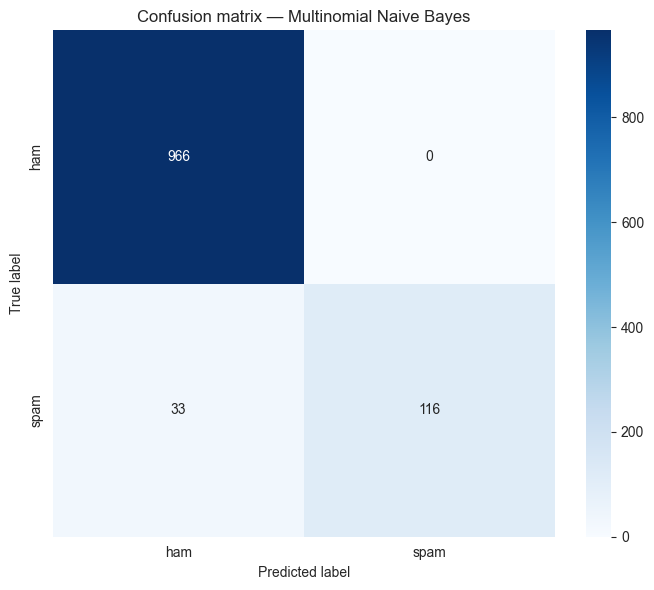


Detailed classification report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam'],
    ax=ax
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion matrix — Multinomial Naive Bayes')
plt.tight_layout()
plt.show()

print('\nDetailed classification report:')
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

## 7. Initial Observations

Findings from this baseline:

- Naive Bayes achieves high accuracy, but accuracy alone is misleading on this imbalanced dataset.
- Precision is very high (the model rarely flags ham messages as spam) — important for user experience.
- Recall is notably lower than precision — meaning some spam messages slip through. This is a known characteristic of Naive Bayes on imbalanced datasets and will be revisited.
- Training and inference times are extremely low — this is the operational efficiency baseline against which DistilBERT will later be compared.

## Next Steps

- Implement SVM and Logistic Regression as additional classical baselines.
- Begin fine-tuning DistilBERT on Google Colab.
- Set up the operational metrics measurement protocol (training time, inference latency, model size, memory footprint) under a unified benchmarking environment.